# Studi Kasus 3: Sifat Termodinamika Model Ising 2D pada Fase Paramagnetik (T = 4.0)

## 1. Konteks Fisis
Dalam mekanika statistik, ketika sebuah material feromagnetik dipanaskan melebihi suhu kritisnya, sifat kemagnetannya akan hilang secara mendadak. Pada Kasus 3 ini, sistem disimulasikan pada suhu tinggi $T = 4.0$, yang berada jauh di atas suhu kritis Onsager ($T_c \approx 2.27$). 

Pada rezim suhu tinggi ini, **energi termal ($k_B T$)** mendominasi jalannya sistem secara mutlak dan mengalahkan gaya pertukaran feromagnetik ($J$) yang berusaha menyelaraskan spin. Fluktuasi termal yang sangat kuat ini menyuntikkan keacakan maksimum ke dalam kisi, menghancurkan memori keteraturan jarak jauh (*long-range order*), dan memaksa material bertransisi sepenuhnya menjadi **fase paramagnetik**.

## 2. Ekspektasi Matematis
Berdasarkan Hamiltonian Model Ising tanpa medan magnet luar:
$$E = -J \sum_{\langle i,j \rangle} s_i s_j$$

Perubahan energi lokal ($\Delta E$) saat suatu spin $s_i$ dibalik tetap dihitung dari 4 tetangganya dengan kondisi batas periodik:
$$\Delta E = 2 s_i \sum_{j \in \text{neighbors}} s_j$$

Pada $T = 4.0$, aturan penerimaan Algoritma Metropolis menunjukkan perilaku yang berbeda dibandingkan suhu rendah:
1. Jika pembalikan spin menurunkan energi ($\Delta E \le 0$), langkah tersebut **selalu diterima**.
2. Jika pembalikan spin justru menaikkan energi ($\Delta E > 0$), langkah tersebut diterima dengan probabilitas Boltzmann:
   $$\mathcal{R} = e^{-\frac{\Delta E}{4.0}}$$
   Karena nilai pembagi suhunya besar ($T=4.0$), nilai eksponensial $\mathcal{R}$ menjadi cukup besar. Artinya, probabilitas sistem untuk menerima konfigurasi yang "acak dan tidak teratur" menjadi sangat tinggi. 

Akibat tingginya toleransi terhadap keacakan ini, arah spin $+1$ (up) dan $-1$ (down) akan terdistribusi secara merata di dalam kisi. Secara statistik, keduanya akan saling meniadakan sehingga nilai magnetisasi rata-rata netto ($M$) akan berosilasi sangat tipis di sekitar angka nol:
$$M = \frac{1}{N^2} \sum_{i=1}^{N^2} s_i \approx 0$$

---

## 3. Implementasi Komputasi

Menjalankan simulasi untuk Case 3 (T = 4.0). Silakan tunggu...


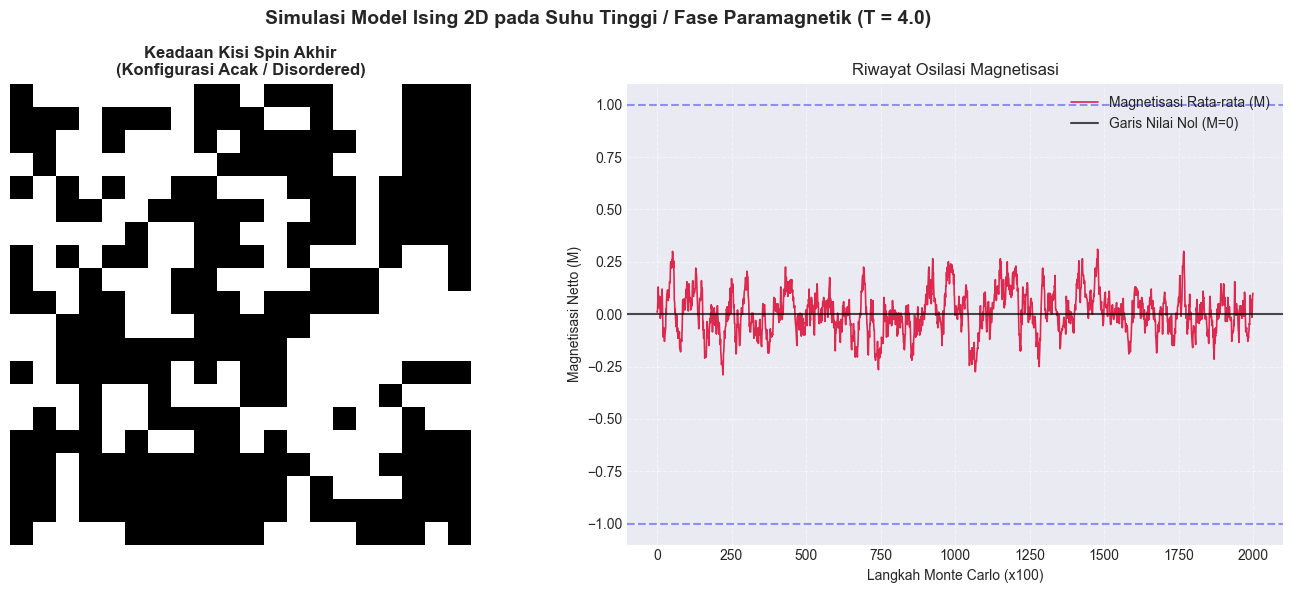

Simulasi Case 3 selesai dieksekusi!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Mengaktifkan gaya plot akademis yang bersih
plt.style.use('seaborn-v0_8-darkgrid')

def metropolis_step(grid, T):
    """Melakukan satu langkah percobaan pembalikan spin menggunakan algoritma Metropolis."""
    N = grid.shape[0]
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    
    s_neighbors = (
        grid[(x+1)%N, y] +
        grid[(x-1)%N, y] +
        grid[x, (y+1)%N] +
        grid[x, (y-1)%N]
    )
    
    delta_E = 2 * grid[x, y] * s_neighbors
    
    if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
        grid[x, y] *= -1  # Terima pembalikan spin
        
    return grid

def run_simulation(N=20, temp=4.0, n_steps=200000):
    """Menjalankan loop Monte Carlo penuh untuk fase paramagnetik."""
    grid = np.random.choice([-1, 1], size=(N, N)) # Hot Start
    magnetization_history = []
    
    for step in range(n_steps):
        grid = metropolis_step(grid, temp)
        
        if step % 100 == 0:
            magnetization = np.mean(grid)
            magnetization_history.append(magnetization)
            
    return grid, magnetization_history

# --- Parameter Eksperimen Kasus 3 ---
GRID_SIZE = 20
MONTE_CARLO_STEPS = 200000  # Sesuai modul bapaknya. Ubah ke 20000 jika ingin tes cepat.
T_CASE = 4.0

print(f"Menjalankan simulasi untuk Case 3 (T = {T_CASE}). Silakan tunggu...")
final_grid, M_history = run_simulation(N=GRID_SIZE, temp=T_CASE, n_steps=MONTE_CARLO_STEPS)

# --- Visualisasi Hasil Subplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Simulasi Model Ising 2D pada Suhu Tinggi / Fase Paramagnetik (T = {T_CASE})", fontsize=14, fontweight='bold')

# Subplot 1: Konfigurasi Kisi Akhir Spin
axes[0].imshow(final_grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title("Keadaan Kisi Spin Akhir\n(Konfigurasi Acak / Disordered)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Subplot 2: Riwayat Magnetisasi Rata-rata
axes[1].plot(M_history, color='crimson', alpha=0.9, linewidth=1.2, label='Magnetisasi Rata-rata (M)')
axes[1].axhline(1.0, color='blue', linestyle='--', alpha=0.4)
axes[1].axhline(0.0, color='black', linestyle='-', alpha=0.7, label='Garis Nilai Nol (M=0)')
axes[1].axhline(-1.0, color='blue', linestyle='--', alpha=0.4)
axes[1].set_title("Riwayat Osilasi Magnetisasi", fontsize=12)
axes[1].set_xlabel("Langkah Monte Carlo (x100)")
axes[1].set_ylabel("Magnetisasi Netto (M)")
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("Simulasi Case 3 selesai dieksekusi!")

## 4. Diskusi & Interpretasi Fisis

Berdasarkan grafik dan visualisasi yang diperoleh dari hasil simulasi Model Ising 2D pada suhu tinggi ($T = 4.0$), kita dapat menarik kesimpulan ilmiah sebagai berikut:

* **Analisis Spasial Konfigurasi Kisi:** Gambar visualisasi grid akhir tidak lagi membentuk blok warna monokromatik tunggal seperti pada Kasus 1, melainkan menghasilkan pola "bising" acak menyerupai papan catur yang rusak. Piksel hitam (spin $+1$) dan piksel putih (spin $-1$) saling bercampur secara merata tanpa membentuk domain makroskopis yang jelas. Hal ini membuktikan secara visual bahwa interaksi penyelarasan antar-spin telah dihancurkan total oleh fluktuasi termal, menciptakan keadaan **disorder (tidak teratur)**.
* **Analisis Riwayat Magnetisasi:** Kurva magnetisasi rata-rata menunjukkan bahwa sejak awal simulasi hingga langkah terakhir, nilai $M$ secara konsisten berosilasi sangat tipis di sekitar garis horizontal nol ($M \approx 0$). Ketiadaan lonjakan konvergensi ke nilai ekstrim ($+1$ atau $-1$) menandakan bahwa tidak terjadi magnetisasi spontan pada suhu tinggi. Secara mekanika statistik, jumlah spin yang menghadap ke atas dan ke bawah sama besar sehingga saling meniadakan secara netto, yang menjadi ciri khas mutlak dari material dalam **fase paramagnetik**..